# Explorative Datenanalyse der Pokémon-Daten

In diesem Notebook wird der aufbereitete Pokémon-Datensatz untersucht.

## Ziele

- Struktur und Datentypen prüfen
- fehlende und doppelte Werte erkennen
- Verteilungen der Basiswerte untersuchen
- Unterschiede zwischen Pokémon-Typen analysieren
- Erkenntnisse für das spätere Empfehlungssystem ableiten

In [1]:
from pathlib import Path

import pandas as pd


# VS Code startet Notebooks normalerweise im Projektordner.
# Falls das Notebook aus dem Ordner "notebooks" gestartet wird,
# wechseln wir eine Ebene nach oben zum Projektordner.
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pokemon.csv"

# Abbruch falls der Datensatz nicht gefunden wird.
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Der Datensatz wurde nicht gefunden: {DATA_PATH}")

pokemon = pd.read_csv(DATA_PATH)

print(f"Datei: {DATA_PATH}")
print(f"Zeilen: {pokemon.shape[0]}")
print(f"Spalten: {pokemon.shape[1]}")

pokemon.head()

Datei: c:\Users\Gian\Data Scientist\pokemon-team-advisor\pokemon-team-advisor\data\processed\pokemon.csv
Zeilen: 1025
Spalten: 13


,id,name,is_default,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,base_stat_total,sprite_url
0,1,bulbasaur,True,grass,poison,45,49,49,65,65,45,318,https://raw.githubusercontent.com/PokeAPI/spri...
1,2,ivysaur,True,grass,poison,60,62,63,80,80,60,405,https://raw.githubusercontent.com/PokeAPI/spri...
2,3,venusaur,True,grass,poison,80,82,83,100,100,80,525,https://raw.githubusercontent.com/PokeAPI/spri...
3,4,charmander,True,fire,NaN,39,52,43,60,50,65,309,https://raw.githubusercontent.com/PokeAPI/spri...
4,5,charmeleon,True,fire,NaN,58,64,58,80,65,80,405,https://raw.githubusercontent.com/PokeAPI/spri...


## 1. Struktur des Datensatzes

Zuerst werden Spalten, Datentypen und fehlende Werte geprüft. Dadurch erkennen wir,
ob numerische Merkmale korrekt eingelesen wurden und welche Spalten vor der Analyse
noch behandelt werden müssen.

In [ ]:
# Die Übersicht verbindet Datentyp, fehlende Werte und Anzahl
# unterschiedlicher Ausprägungen für jede Spalte.
structure = pd.DataFrame(
    {
        "datentyp": pokemon.dtypes.astype(str),
        "fehlende_werte": pokemon.isna().sum(),
        "eindeutige_werte": pokemon.nunique(dropna=True),
    }
)


structure

Eindeutige Sprite-URLs: 1025
Doppelte Sprite-URLs: 0


,datentyp,fehlende_werte,eindeutige_werte
id,int64,0,1025
name,object,0,1025
is_default,bool,0,1
type_1,object,0,18
type_2,object,499,18
hp,int64,0,107
attack,int64,0,117
defense,int64,0,108
special_attack,int64,0,113
special_defense,int64,0,103


## 2. Datenqualität

Vor der statistischen Analyse wird geprüft, ob IDs und Namen eindeutig sind,
Basiswerte fehlen oder ungültig sind und die berechnete Gesamtsumme stimmt.

In [5]:
# Diese sechs Spalten bilden die Basiswerte eines Pokémon.
STAT_COLUMNS = [
    "hp",
    "attack",
    "defense",
    "special_attack",
    "special_defense",
    "speed",
]

# Die gespeicherte Gesamtsumme muss der Summe der sechs Basiswerte entsprechen.
calculated_total = pokemon[STAT_COLUMNS].sum(axis=1)

# Jede Prüfung liefert True, wenn die jeweilige Qualitätsregel erfüllt ist.
quality_checks = pd.Series(
    {
        "IDs sind eindeutig": pokemon["id"].is_unique,
        "Namen sind eindeutig": pokemon["name"].is_unique,
        "nur Standardformen enthalten": pokemon["is_default"].all(),
        "nach ID sortiert": pokemon["id"].is_monotonic_increasing,
        "keine fehlenden Basiswerte": not pokemon[STAT_COLUMNS].isna().any().any(),
        "alle Basiswerte sind positiv": pokemon[STAT_COLUMNS].gt(0).all().all(),
        "Gesamtsumme ist korrekt": calculated_total.equals(pokemon["base_stat_total"]),
        "Primär- und Sekundärtyp unterscheiden sich": pokemon.loc[
            pokemon["type_2"].notna(), "type_1"
        ]
        .ne(pokemon.loc[pokemon["type_2"].notna(), "type_2"])
        .all(),
        "Sprite-URLs sind vollständig": pokemon["sprite_url"].notna().all(),
    },
    name="bestanden",
)

quality_checks

IDs sind eindeutig                            True
Namen sind eindeutig                          True
nur Standardformen enthalten                  True
nach ID sortiert                              True
keine fehlenden Basiswerte                    True
alle Basiswerte sind positiv                  True
Gesamtsumme ist korrekt                       True
Primär- und Sekundärtyp unterscheiden sich    True
Sprite-URLs sind vollständig                  True
Name: bestanden, dtype: bool

## 3. Verteilung der Basiswerte

Die deskriptive Statistik zeigt Lage, Streuung und Spannweite der sechs Basiswerte.
So lassen sich typische Werte und mögliche Ausreißer erkennen.

In [6]:
# base_stat_total wird zusätzlich betrachtet, weil diese Spalte die allgemeine
# Stärke eines Pokémon zusammenfasst.
numeric_columns = [*STAT_COLUMNS, "base_stat_total"]

# describe() berechnet Anzahl, Mittelwert, Standardabweichung,
# Quartile sowie Minimum und Maximum.
stat_summary = pokemon[numeric_columns].describe().T

# Durch die Transposition steht jeder Basiswert in einer eigenen Zeile.
stat_summary.round(2)

,count,mean,std,min,25%,50%,75%,max
hp,1025.0,70.18,26.63,1.0,50.0,68.0,85.0,255.0
attack,1025.0,77.52,29.78,5.0,55.0,75.0,100.0,181.0
defense,1025.0,72.51,29.29,5.0,50.0,70.0,90.0,230.0
special_attack,1025.0,70.08,29.66,10.0,47.0,65.0,90.0,173.0
special_defense,1025.0,70.21,26.64,20.0,50.0,67.0,86.0,230.0
speed,1025.0,67.19,28.72,5.0,45.0,65.0,88.0,200.0
base_stat_total,1025.0,427.69,112.77,175.0,325.0,450.0,508.0,720.0


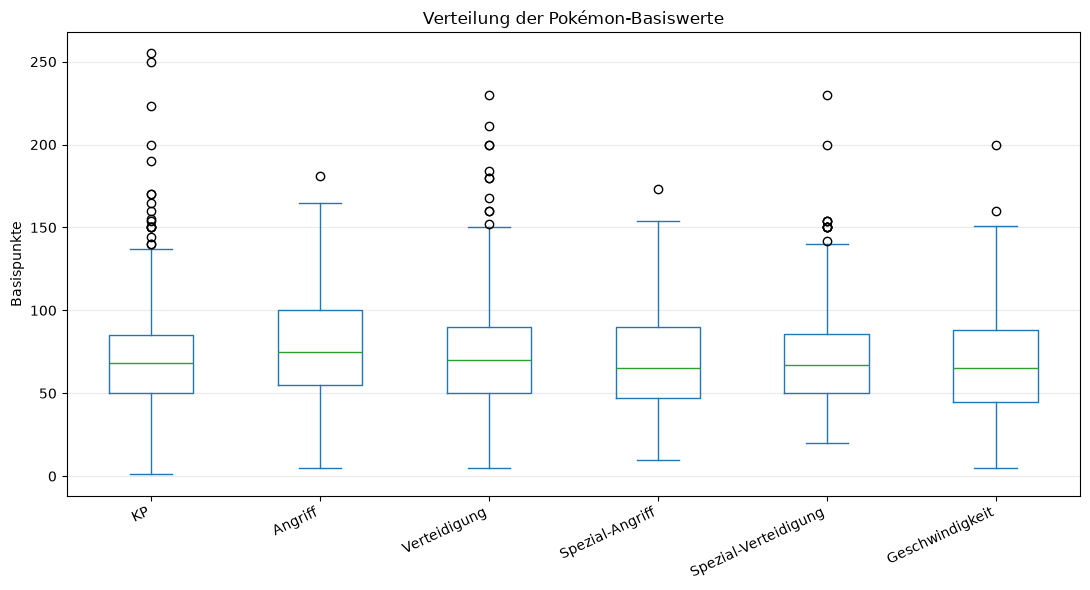

In [7]:
import matplotlib.pyplot as plt


# Verständliche deutsche Namen verbessern die Lesbarkeit der Grafik.
stat_labels = {
    "hp": "KP",
    "attack": "Angriff",
    "defense": "Verteidigung",
    "special_attack": "Spezial-Angriff",
    "special_defense": "Spezial-Verteidigung",
    "speed": "Geschwindigkeit",
}

plot_data = pokemon[STAT_COLUMNS].rename(columns=stat_labels)

fig, ax = plt.subplots(figsize=(11, 6))

plot_data.plot(
    kind="box",
    ax=ax,
    showfliers=True,
)

ax.set_title("Verteilung der Pokémon-Basiswerte")
ax.set_ylabel("Basispunkte")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Angriff besitzt den höchsten Median der sechs Basiswerte. Die mittleren 50 % der
Werte überlappen sich jedoch deutlich, weshalb kein einzelner Stat die Mehrheit der
Pokémon klar voneinander trennt.

Besonders bei KP, Verteidigung und Spezial-Verteidigung treten hohe Ausreißer auf.
Diese Werte werden nicht entfernt, da sie plausible Spezialisierungen einzelner
Pokémon darstellen und für das spätere Rollenmodell wichtig sein können.

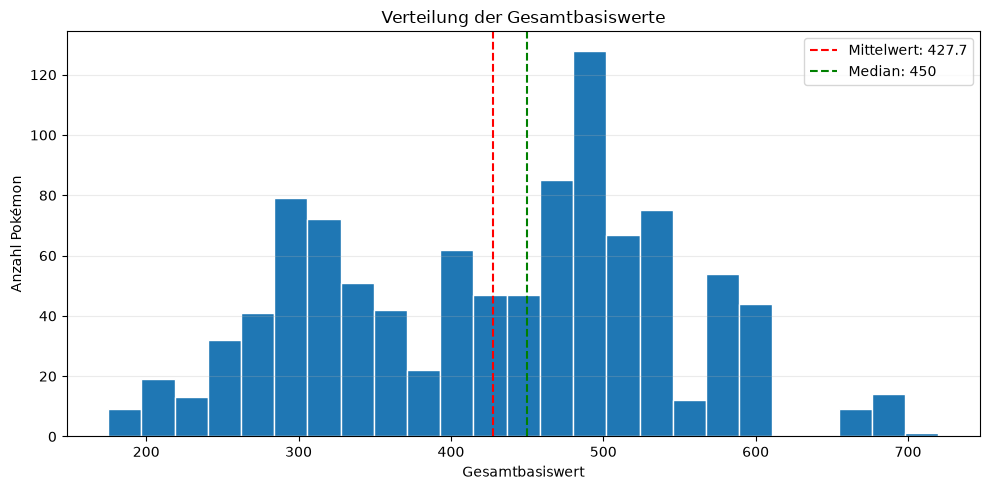

In [8]:
# Mittelwert und Median helfen uns, die Form der Verteilung einzuschätzen.
mean_total = pokemon["base_stat_total"].mean()
median_total = pokemon["base_stat_total"].median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    pokemon["base_stat_total"],
    bins=25,
    edgecolor="white",
)

# Die beiden Linien zeigen, ob hohe oder niedrige Werte die Verteilung verschieben.
ax.axvline(
    mean_total,
    color="red",
    linestyle="--",
    label=f"Mittelwert: {mean_total:.1f}",
)
ax.axvline(
    median_total,
    color="green",
    linestyle="--",
    label=f"Median: {median_total:.0f}",
)

ax.set_title("Verteilung der Gesamtbasiswerte")
ax.set_xlabel("Gesamtbasiswert")
ax.set_ylabel("Anzahl Pokémon")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

Die Gesamtbasiswerte sind nicht normalverteilt, sondern zeigen mehrere Häufungen.
Besonders viele Pokémon liegen im Bereich um 500 Punkte, während eine weitere größere
Gruppe deutlich niedrigere Gesamtwerte besitzt.

Der Mittelwert liegt unter dem Median, weil Pokémon mit niedrigen Gesamtwerten den
Mittelwert nach unten ziehen. Entwicklungsstufen könnten diese Gruppen teilweise
erklären. Diese Vermutung kann mit den aktuell vorhandenen Merkmalen jedoch noch
nicht überprüft werden.

In [9]:
# Ein Histogramm gruppiert Werte in Intervalle. Mit value_counts()
# sehen wir ergänzend, welche exakten Gesamtwerte am häufigsten vorkommen.
common_totals = (
    pokemon["base_stat_total"]
    .value_counts()
    .head(10)
    .rename_axis("Gesamtbasiswert")
    .reset_index(name="Anzahl Pokémon")
)

common_totals

,Gesamtbasiswert,Anzahl Pokémon
0,600,36
1,500,33
2,570,30
3,490,26
4,405,26
5,580,24
6,300,24
7,530,23
8,485,22
9,525,21


## 4. Verteilung der Pokémon-Typen

Für die Typenverteilung werden Primär- und Sekundärtypen gemeinsam gezählt.
Ein Pokémon mit zwei Typen trägt daher zu zwei Typzuordnungen bei.

Typzuordnungen insgesamt: 1551


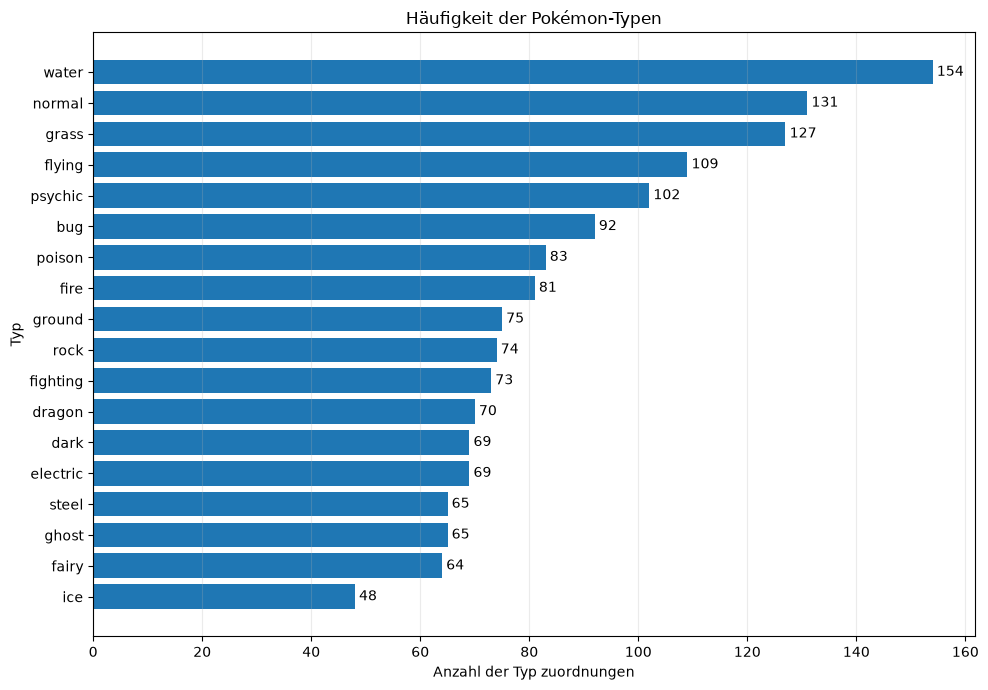

In [11]:
# Der Primärtyp ist immer vorhanden. Fehlende Sekundärtypen werden entfernt,
# weil sie Einzeltypen und keine unbekannten Werte darstellen.
type_memberships = pd.concat(
    [
        pokemon["type_1"],
        pokemon["type_2"].dropna(),
    ],
    ignore_index=True,
)

# Für den horizontalen Plot sortieren wir aufsteigend,
# sodass der häufigste Typ oben erscheint.
type_counts = type_memberships.value_counts().sort_values()

print(f"Typzuordnungen insgesamt: {len(type_memberships)}")

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    type_counts.index,
    type_counts.values,
)

# Die konkreten Anzahlen werden direkt an die Balken geschrieben.
ax.bar_label(bars, padding=3)

ax.set_title("Häufigkeit der Pokémon-Typen")
ax.set_xlabel("Anzahl der Typ zuordnungen")
ax.set_ylabel("Typ")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

Die Typen sind nicht gleichmäßig verteilt. Wasser, Normal und Pflanze treten besonders
häufig auf, während Eis deutlich seltener vertreten ist.

Diese Ungleichverteilung muss bei der späteren Bewertung berücksichtigt werden.
Andernfalls könnten häufige Typen allein aufgrund der größeren Kandidatenmenge öfter
in den Empfehlungen erscheinen.

In [12]:
# Für diese Analyse bringen wir type_1 und type_2 in eine gemeinsame Spalte.
# Ein dualtypisches Pokémon erscheint dadurch einmal für jeden seiner beiden Typen.
pokemon_by_type = pokemon.melt(
    id_vars=["id", "name", *STAT_COLUMNS],
    value_vars=["type_1", "type_2"],
    var_name="type_position",
    value_name="type",
).dropna(subset=["type"])

# Für jeden Typ berechnen wir den Mittelwert der sechs Basiswerte.
type_stat_means = pokemon_by_type.groupby("type")[STAT_COLUMNS].mean().round(1)

type_stat_means

,hp,attack,defense,special_attack,special_defense,speed
type,,,,,,
bug,56.6,68.0,69.2,56.8,64.2,60.2
dark,76.3,93.6,71.4,72.7,68.9,76.8
dragon,84.1,94.0,83.0,87.2,78.3,78.2
electric,68.7,74.9,64.9,84.2,67.7,81.9
fairy,67.2,64.7,70.1,77.2,83.9,65.7
fighting,77.8,104.3,76.4,63.6,69.7,75.4
fire,69.9,80.6,67.5,86.3,71.0,74.1
flying,70.4,76.7,65.6,71.6,68.5,82.4
ghost,65.7,77.4,77.5,81.6,79.1,66.2


### Durchschnittliche Stats nach Typ

Die Typen zeigen unterschiedliche statistische Profile. Kampf-Pokémon besitzen
durchschnittlich einen besonders hohen Angriff, während Stahl- und Gestein-Pokémon
durch hohe Verteidigungswerte auffallen. Psycho ist besonders stark bei den
Spezialwerten; Flug und Elektro besitzen die höchste durchschnittliche Geschwindigkeit.

Die Ergebnisse beschreiben Zusammenhänge und keine kausale Wirkung des Typs.
Dualtypische Pokémon gehen in beide zugehörigen Typgruppen ein. Außerdem unterscheiden
sich die Gruppengrößen, weshalb Mittelwerte seltener Typen weniger stabil sein können.

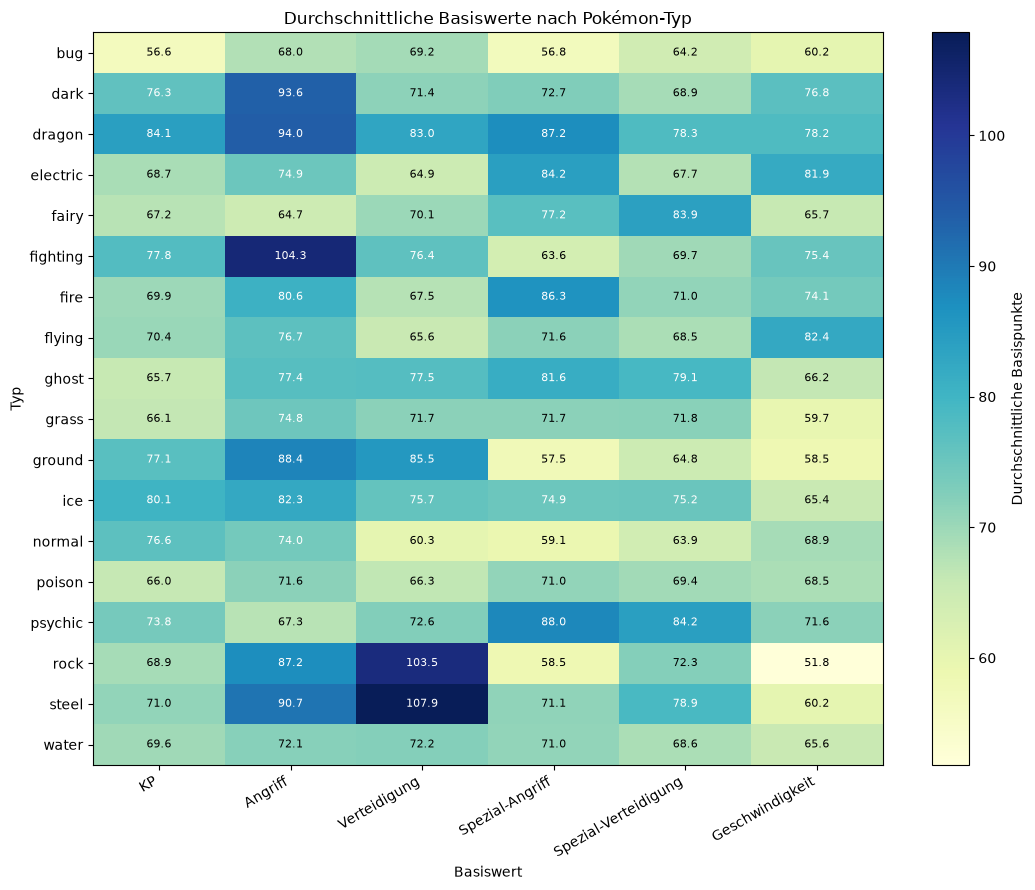

In [14]:
# Die Heatmap macht hohe und niedrige Mittelwerte über viele Typen
# und Stats hinweg schneller vergleichbar als die reine Tabelle.
fig, ax = plt.subplots(figsize=(11, 9))

heatmap = ax.imshow(
    type_stat_means.values,
    cmap="YlGnBu",
    aspect="auto",
)

ax.set_xticks(range(len(STAT_COLUMNS)))
ax.set_xticklabels(
    [
        "KP",
        "Angriff",
        "Verteidigung",
        "Spezial-Angriff",
        "Spezial-Verteidigung",
        "Geschwindigkeit",
    ],
    rotation=30,
    ha="right",
)

ax.set_yticks(range(len(type_stat_means.index)))
ax.set_yticklabels(type_stat_means.index)

# Jede Zelle erhält zusätzlich ihren genauen Mittelwert.
# Bei dunklem Hintergrund verwenden wir weiße Schrift.
color_threshold = type_stat_means.to_numpy().mean()

for row_index in range(type_stat_means.shape[0]):
    for column_index in range(type_stat_means.shape[1]):
        value = type_stat_means.iloc[row_index, column_index]
        text_color = "white" if value > color_threshold else "black"

        ax.text(
            column_index,
            row_index,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
        )

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label("Durchschnittliche Basispunkte")

ax.set_title("Durchschnittliche Basiswerte nach Pokémon-Typ")
ax.set_xlabel("Basiswert")
ax.set_ylabel("Typ")

plt.tight_layout()
plt.show()

### Interpretation der Typ-Profile

Die Heatmap zeigt mehrere charakteristische Typ-Profile. Stahl und Gestein besitzen
hohe durchschnittliche Verteidigungswerte, während Kampf durch hohen physischen
Angriff auffällt. Psycho, Feuer und Elektro zeigen erhöhte Spezial-Angriffswerte.
Flug und Elektro sind im Durchschnitt besonders schnell.

Die Unterschiede können nicht ausschließlich dem Typ zugeschrieben werden.
Dualtypen, unterschiedliche Gesamtbasiswerte und die ungleichen Gruppengrößen
beeinflussen die Mittelwerte ebenfalls.

In [17]:
# Aus dem fehlenden oder vorhandenen Sekundärtyp erzeugen wir
# ein verständliches kategoriales Merkmal.
pokemon["type_structure"] = (
    pokemon["type_2"]
    .notna()
    .map(
        {
            False: "Ein Typ",
            True: "Zwei Typen",
        }
    )
)

# Wir vergleichen Anzahl, Mittelwert, Median und Streuung
# der Gesamtbasiswerte beider Gruppen.
type_structure_summary = (
    pokemon.groupby("type_structure")["base_stat_total"]
    .agg(
        anzahl="size",
        mittelwert="mean",
        median="median",
        standardabweichung="std",
    )
    .round(1)
)

type_structure_summary

,anzahl,mittelwert,median,standardabweichung
type_structure,,,,
Ein Typ,499,403.1,410.0,110.9
Zwei Typen,526,451.0,479.5,109.6


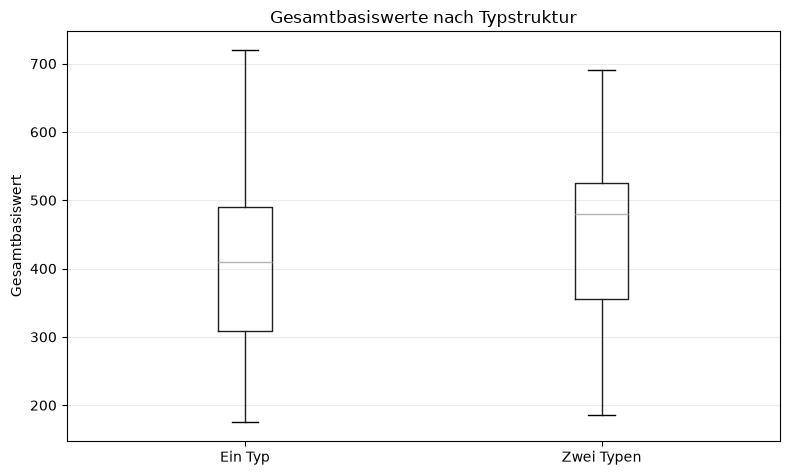

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

pokemon.boxplot(
    column="base_stat_total",
    by="type_structure",
    ax=ax,
    grid=False,
)

# Pandas erzeugt automatisch einen zusätzlichen Gesamttitel,
# den wir für eine sauberere Darstellung entfernen.
plt.suptitle("")

ax.set_title("Gesamtbasiswerte nach Typstruktur")
ax.set_xlabel("")
ax.set_ylabel("Gesamtbasiswert")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Einzeltypen und Dualtypen

Pokémon mit zwei Typen besitzen im aktuellen Datensatz einen höheren durchschnittlichen
und medianen Gesamtbasiswert als Pokémon mit nur einem Typ. Die Streuung ist in beiden
Gruppen ähnlich, und die Wertebereiche überlappen deutlich.

Der beobachtete Unterschied ist kein Nachweis dafür, dass ein zweiter Typ höhere
Basiswerte verursacht. Andere Merkmale wie Entwicklungsstufe oder Pokémon-Kategorie
könnten den Zusammenhang beeinflussen.

In [19]:
# Die Namen hinter Minimum und Maximum helfen uns zu prüfen,
# ob extreme Werte zu plausiblen Pokémon gehören.
extreme_rows = []

for stat in STAT_COLUMNS:
    minimum = pokemon[stat].min()
    maximum = pokemon[stat].max()

    minimum_names = ", ".join(pokemon.loc[pokemon[stat].eq(minimum), "name"])
    maximum_names = ", ".join(pokemon.loc[pokemon[stat].eq(maximum), "name"])

    extreme_rows.append(
        {
            "Stat": stat_labels[stat],
            "Minimum": minimum,
            "Pokémon mit Minimum": minimum_names,
            "Maximum": maximum,
            "Pokémon mit Maximum": maximum_names,
        }
    )

stat_extremes = pd.DataFrame(extreme_rows).set_index("Stat")

stat_extremes

,Minimum,Pokémon mit Minimum,Maximum,Pokémon mit Maximum
Stat,,,,
KP,1,shedinja,255,blissey
Angriff,5,"chansey, happiny",181,kartana
Verteidigung,5,"chansey, happiny",230,shuckle
Spezial-Angriff,10,"shuckle, feebas, bonsly",173,xurkitree
Spezial-Verteidigung,20,"caterpie, weedle, magikarp, igglybuff, carvanh...",230,shuckle
Geschwindigkeit,5,"shuckle, munchlax, pyukumuku",200,regieleki


### Prüfung der Extremwerte

Die Pokémon hinter den minimalen und maximalen Stats sind fachlich plausible
Spezialfälle. Shedinjas einzelner KP sowie Shuckles sehr hohe Verteidigungswerte
sind beispielsweise beabsichtigte Eigenschaften.

Die Ausreißer werden deshalb nicht entfernt. Sie enthalten wichtige Informationen
über spezialisierte Pokémon und können später bei der Bestimmung von Rollen wie
Tank, physischer Angreifer oder schneller Angreifer helfen.

## Korrelationen zwischen den Basiswerten

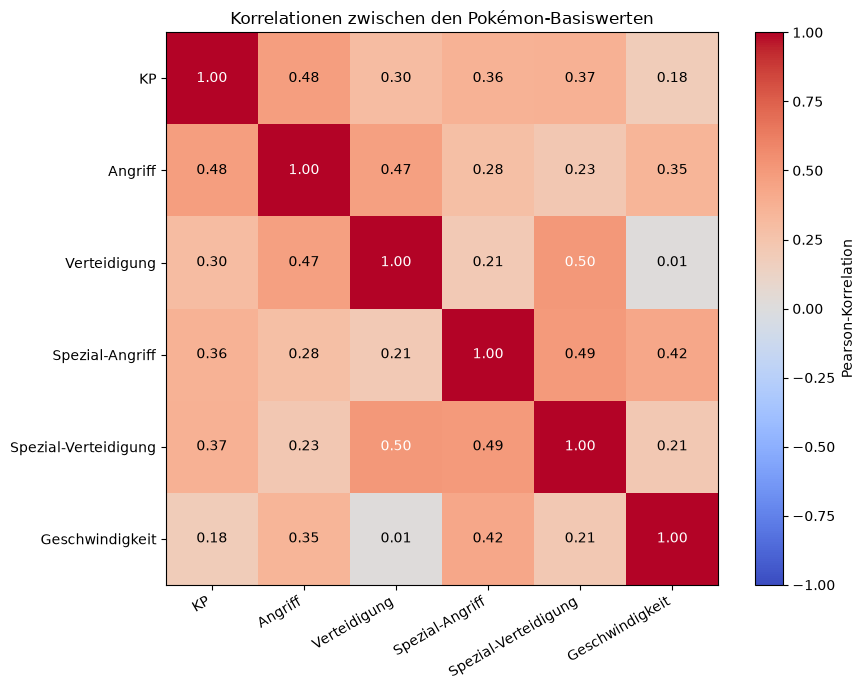

In [16]:
# Die Pearson-Korrelation liegt zwischen -1 und 1:
#  1 = beide Werte steigen häufig gemeinsam
#  0 = kein linearer Zusammenhang
# -1 = ein Wert steigt, während der andere fällt
stat_correlations = pokemon[STAT_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9, 7))

correlation_heatmap = ax.imshow(
    stat_correlations.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

correlation_labels = [
    "KP",
    "Angriff",
    "Verteidigung",
    "Spezial-Angriff",
    "Spezial-Verteidigung",
    "Geschwindigkeit",
]

ax.set_xticks(range(len(correlation_labels)))
ax.set_xticklabels(correlation_labels, rotation=30, ha="right")
ax.set_yticks(range(len(correlation_labels)))
ax.set_yticklabels(correlation_labels)

# Die Zahlen verhindern, dass wir uns nur auf die Farbwirkung verlassen.
for row_index in range(stat_correlations.shape[0]):
    for column_index in range(stat_correlations.shape[1]):
        value = stat_correlations.iloc[row_index, column_index]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) >= 0.5 else "black",
        )

colorbar = fig.colorbar(correlation_heatmap, ax=ax)
colorbar.set_label("Pearson-Korrelation")

ax.set_title("Korrelationen zwischen den Pokémon-Basiswerten")

plt.tight_layout()
plt.show()

### Interpretation der Korrelationen

Zwischen den Basiswerten bestehen überwiegend schwache bis moderate positive
Zusammenhänge. Die stärkste beobachtete Korrelation besteht zwischen Verteidigung
und Spezial-Verteidigung. Zwischen Verteidigung und Geschwindigkeit ist dagegen praktisch
kein linearer Zusammenhang erkennbar.

Die positiven Korrelationen können teilweise dadurch entstehen, dass Pokémon mit
hohem Gesamtbasiswert häufig in mehreren Stats hohe Werte besitzen. Aus den
Korrelationen lässt sich daher keine Ursache ableiten.

Für das spätere Rollenmodell sollten die einzelnen Stats standardisiert und relativ
zueinander betrachtet werden. Dadurch können beispielsweise physische Angreifer,
spezielle Angreifer und defensive Pokémon unterschieden werden.

## Fazit

Der Datensatz enthält 1.025 eindeutige Standardformen und erfüllt alle geprüften
Qualitätsregeln. Die Gesamtbasiswerte sind mehrgipflig verteilt und zeigen mehrere
wiederkehrende Stärkebereiche.

Die Pokémon-Typen sind unterschiedlich häufig vertreten und weisen erkennbare
Stat-Profile auf. Gleichzeitig überlappen sich die Verteilungen deutlich, sodass ein
Typ allein keine Rolle zuverlässig bestimmt.

Die sechs Basiswerte liefern weitgehend eigenständige Informationen und bilden damit
eine geeignete Grundlage für die spätere Typen-, Rollen- und Team-Analyse.